# **EMBEDDING CONTEXTUAL PARA A IDENTIFICAÇÃO DE SINÔNIMOS**
**Nome:** Gisela Kassick e Lívia Aragão

## Importações

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import textwrap

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import unicodedata
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

## Configurações

In [2]:
ARQUIVO_ENTRADA = "extracao_com_material_extraido.xlsx"

ARQUIVO_SAIDA = "materiais_normalizados_contextual.xlsx"

COLUNA_MATERIAL = "material_extraído"

COLUNA_NORMALIZADA = "material_normalizado"

COLUNA_GRUPO = "grupo_material"

COLUNA_SIMILARIDADE = "similaridade_grupo"

# Sobre o embedding
MODELO = "all-mpnet-base-v2"

LIMIAR_COMPONENTE = 0.92

LIMIAR_REVISAO = 0.80

# Nomes com menos caracteres que isso (ex.: "Ag", "LIG") só juntam via dicionário.
TAM_MIN_CHAVE = 5

## Carregar dados

In [3]:
print("CARREGANDO DATASET")

df = pd.read_excel(ARQUIVO_ENTRADA)

print(f"Linhas encontradas: {len(df)}")
print(f"Colunas encontradas:\n{df.columns.tolist()}")


# Verificar coluna
if COLUNA_MATERIAL not in df.columns:
    raise ValueError(f"A coluna '{COLUNA_MATERIAL}' nao foi encontrada no Excel.")

CARREGANDO DATASET
Linhas encontradas: 546
Colunas encontradas:
['Title', 'Year', 'Authors', 'Journal', 'DOI', 'Abstract', 'Citations', 'Type', 'Language', 'Open Access', 'PDF', 'Landing Page', 'OpenAlex ID', 'abstract_limpo', 'contexto_electrode', 'material_extraído']


## Limpeza

In [4]:
def limpar_material(texto):

    if pd.isna(texto):
        return ""

    texto = str(texto)
    texto = texto.strip()

    # Remove espacos duplicados
    texto = re.sub(r"\s+", " ", texto)

    return texto

df["material_limpo"] = (df[COLUNA_MATERIAL].apply(limpar_material))

# Separando materiais vazios
materiais_validos = (df.loc[df["material_limpo"] != "","material_limpo"].drop_duplicates().tolist())

print()
print("MATERIAIS")

print(f"Materiais distintos: {len(materiais_validos)}")


MATERIAIS
Materiais distintos: 185


## Criar embeddings

In [5]:
print()
print("CARREGANDO MODELO")

print(f"Modelo: {MODELO}")

modelo = SentenceTransformer(MODELO)

print()
print("GERANDO EMBEDDINGS")

embeddings = modelo.encode(materiais_validos, normalize_embeddings=True, show_progress_bar=True)

print(f"Dimensao dos embeddings: {embeddings.shape}")



CARREGANDO MODELO
Modelo: all-mpnet-base-v2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


GERANDO EMBEDDINGS


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Dimensao dos embeddings: (185, 768)


## Agrupamento de sinônimos

## Dicionário de sinônimos

In [6]:
ABREVIACOES = {
    # elementos / metais
    "ag": "silver", "prata": "silver", "au": "gold", "cu": "copper",
    "al": "aluminum", "aluminium": "aluminum", "ni": "nickel",
    "pt": "platinum", "cr": "chromium",
    # formas
    "nw": "nanowire", "agnw": "silver nanowire",
    # polímeros / compostos
    "pdms": "polydimethylsiloxane", "pva": "polyvinyl alcohol",
    "pvp": "polyvinylpyrrolidone", "tpu": "thermoplastic polyurethane",
    "pet": "polyethylene terephthalate", "ito": "indium tin oxide",
    "rgo": "reduced graphene oxide", "lig": "laser induced graphene",
    "fpc": "flexible printed circuit board", "fpcb": "flexible printed circuit board",
    # nanotubos
    "cnt": "carbon nanotube", "mwcnt": "multiwall carbon nanotube",
    "mwnt": "multiwall carbon nanotube", "swcnt": "singlewall carbon nanotube",
    "swnt": "singlewall carbon nanotube",
    # grafias
    "walled": "wall", "multiwalled": "multiwall", "singlewalled": "singlewall",
}

EQUIVALENCIAS = [
    ["PEDOT:PSS",
     "poly(3,4-ethylenedioxythiophene):poly(styrenesulfonate)",
     "poly(3,4-ethylenedioxythiophene):polystyrene sulfonate",
     "poly(2,3-diydrothieno-1,4-dioxin)-poly(styrenesulfonate)"],
    ["PEDOT", "poly(3,4-ethylenedioxythiophene)"],
]

### Revisão de sinônimos manuais (escolher após rodar a tabela de revisão uma primeira vez)

In [7]:
SINONIMOS_MANUAIS = [
    ["conductive fabric", "conductive textile"], ["conducting polymer","conductive polymer"], 
    ["fabric", "textile", "conductive fabric", "conductive textile"], ["monolayer graphene", "single layer graphene"],
    ["polymeric polyurethane", "polyurethane"]
]

for grupo_sin in SINONIMOS_MANUAIS:
    for nome in grupo_sin:
        prof, virgula = 0, False
        for ch in nome:
            prof += ch in "(["
            prof -= ch in ")]"
            virgula = virgula or (ch == "," and prof == 0)
        if virgula:
            print(f"ATENCAO: '{nome}' tem virgula; use um componente por nome.")

EQUIVALENCIAS.extend(SINONIMOS_MANUAIS)
print(f"Sinonimos manuais carregados: {len(SINONIMOS_MANUAIS)} grupo(s)")

Sinonimos manuais carregados: 5 grupo(s)


## Sinonimia: normalização, componentes e agrupamento

Cada material é dividido em componentes (separados por vírgula). Dois materiais só entram no mesmo grupo se tiverem **exatamente os mesmos componentes** (em qualquer ordem), onde cada componente é comparado a outro apenas por sinonímia (dicionário/abreviação ou embedding muito alto). Materiais que apenas *se parecem* (ex.: `Copper, Nickel` e `Copper, aluminium`) ficam separados.

In [8]:
# NORMALIZAÇÃO

def singularizar(tok):
    if len(tok) > 3 and tok.endswith("s") and not tok.endswith(("ss", "us", "is")):
        return tok[:-1]
    return tok

def tokenizar(texto):
    t = unicodedata.normalize("NFKD", str(texto))
    t = "".join(c for c in t if not unicodedata.combining(c)).lower()
    return [singularizar(x) for x in re.findall(r"[a-z0-9]+", t)]

def tokens_normalizados(texto):
    saida = []
    for tok in tokenizar(texto):
        saida.extend(ABREVIACOES.get(tok, tok).split())
    return saida

def chave(texto):
    return "".join(tokens_normalizados(texto))

MAPA_EQUIV = {}
for lista in EQUIVALENCIAS:
    alvo = chave(lista[0])
    for item in lista:
        MAPA_EQUIV[chave(item)] = alvo

def chave_canonica(texto):
    c = chave(texto) or str(texto).lower().strip()
    return MAPA_EQUIV.get(c, c)


# COMPONENTES

def dividir_componentes(texto):
    partes, atual, prof = [], [], 0
    for ch in texto:
        if ch in "([":
            prof += 1
        elif ch in ")]":
            prof = max(prof - 1, 0)
        if ch == "," and prof == 0:
            partes.append("".join(atual)); atual = []
        else:
            atual.append(ch)
    partes.append("".join(atual))
    return [p.strip() for p in partes if p.strip()]

RE_ABREV = re.compile(r"^(.*\S)\s+[\(\[]([^\(\)\[\]]{1,15})[\)\]]$")

def textos_do_componente(comp):
    m = RE_ABREV.match(comp)
    return [m.group(1), m.group(2)] if m else [comp]

class UnionFind:
    def __init__(self): self.pai = {}
    def achar(self, x):
        self.pai.setdefault(x, x)
        while self.pai[x] != x:
            self.pai[x] = self.pai[self.pai[x]]
            x = self.pai[x]
        return x
    def unir(self, a, b):
        ra, rb = self.achar(a), self.achar(b)
        if ra != rb: self.pai[rb] = ra

def agrupar_sinonimos(materiais, modelo, limiar, limiar_revisao=0.80, tam_min_chave=5):
    # componentes de cada material + identidade exata (dicionário/abreviação)
    uf = UnionFind()
    comps_por_material = []
    texto_da_chave = {}
    for mat in materiais:
        raizes_chaves = []
        for comp in dividir_componentes(mat):
            chaves = [chave_canonica(t) for t in textos_do_componente(comp)]
            for c, t in zip(chaves, textos_do_componente(comp)):
                texto_da_chave.setdefault(c, t)
            for c in chaves[1:]:
                uf.unir(chaves[0], c)
            raizes_chaves.append(chaves[0])
        comps_por_material.append(raizes_chaves)

    raizes = sorted({uf.achar(c) for lst in comps_por_material for c in lst})
    idx = {r: i for i, r in enumerate(raizes)}
    textos = [" ".join(tokens_normalizados(texto_da_chave.get(r, r))) or r for r in raizes]

    # sinônimos entre componentes via embedding (com travas)
    revisao = []
    if len(raizes) > 1:
        emb = modelo.encode(textos, normalize_embeddings=True, show_progress_bar=False)
        S = cosine_similarity(emb)
        toks = [set(t.split()) for t in textos]
        nums = [tuple(re.findall(r"\d+", r)) for r in raizes]
        n = len(raizes)
        D = np.ones((n, n)); np.fill_diagonal(D, 0)
        for i in range(n):
            for j in range(i + 1, n):
                s = S[i, j]
                if s < limiar_revisao:
                    continue
                motivo = None
                if s < limiar: motivo = "abaixo do limiar"
                elif min(len(raizes[i]), len(raizes[j])) < tam_min_chave: motivo = "nome curto (só dicionário)"
                elif nums[i] != nums[j]: motivo = "números diferentes"
                elif toks[i] < toks[j] or toks[j] < toks[i]: motivo = "um é mais específico que o outro"
                if motivo is None:
                    D[i, j] = D[j, i] = 0
                else:
                    revisao.append((textos[i], textos[j], round(float(s), 3), motivo))
        Z = linkage(squareform(D, checks=False), method="complete")
        cl = fcluster(Z, t=0.5, criterion="distance")
    else:
        cl = np.array([1])

    # material = conjunto de componentes semanticamente equivalentes (mesmo conjunto de componentes => sinônimos)
    grupos, assinatura_para_grupo = [], {}
    for lst in comps_por_material:
        assinatura = frozenset(int(cl[idx[uf.achar(c)]]) for c in lst)
        grupos.append(assinatura_para_grupo.setdefault(assinatura, len(assinatura_para_grupo)))
    df_rev = pd.DataFrame(revisao, columns=["componente_a", "componente_b", "similaridade", "motivo"])
    return grupos, df_rev.sort_values("similaridade", ascending=False).reset_index(drop=True)

## Similaridade de cosseno e agrupamento

In [9]:
print("SIMILARIDADE DE COSSENO (somente para relatório)")

matriz_similaridade = cosine_similarity(embeddings)
print(f"Tamanho da matriz: {matriz_similaridade.shape}")

print()
print("AGRUPANDO SINONIMOS")

grupos, df_revisao = agrupar_sinonimos(
    materiais_validos,
    modelo,
    limiar=LIMIAR_COMPONENTE,
    limiar_revisao=LIMIAR_REVISAO,
    tam_min_chave=TAM_MIN_CHAVE,
)

numero_grupo = len(set(grupos))
print(f"Grupos encontrados: {numero_grupo}")

# Tabelas
df_grupos = pd.DataFrame({"material_original": materiais_validos, "grupo": grupos})

print()
print("PARES PARA REVISAO (quase-sinonimos que NAO foram juntados)")
display(df_revisao.head(40))

SIMILARIDADE DE COSSENO (somente para relatório)
Tamanho da matriz: (185, 185)

AGRUPANDO SINONIMOS
Grupos encontrados: 162

PARES PARA REVISAO (quase-sinonimos que NAO foram juntados)


,componente_a,componente_b,similaridade,motivo
0,p silver nanowire,silver nanowire,0.929,um é mais específico que o outro
1,poly 3 4 ethylenedioxythiophene,poly 3 4 ethylenedioxythiophene poly styrenesu...,0.921,um é mais específico que o outro
2,polydimethylsiloxane,polymethylhydrosiloxane,0.914,abaixo do limiar
3,metallic nanowire,silver nanowire,0.890,abaixo do limiar
4,nylon,nylon fiber,0.890,abaixo do limiar
5,multiwall carbon nanotube,single wall carbon nanotube,0.874,abaixo do limiar
6,copper nanowire,metallic nanowire,0.867,abaixo do limiar
7,mxene polyvinyl alcohol hydrogel,polyvinyl alcohol hydrogel,0.863,abaixo do limiar
8,pvdf,pvdf hfp,0.857,abaixo do limiar
9,hydrogen bonded ionic gel,ionic gel,0.847,abaixo do limiar


## Representante do grupo

In [10]:
# Como todos os membros do grupo são sinônimos, o representante é a forma mais frequente no dataset. Em caso de empate, prefere o nome por extenso

contagem = df["material_limpo"].value_counts()

def tamanho_sem_parenteses(texto):
    return len(re.sub(r"\s*[\(\[][^\(\)\[\]]*[\)\]]", "", texto))

representantes = {}
sim_media_representante = {}

for grupo in sorted(df_grupos["grupo"].unique()):

    indices = df_grupos.index[df_grupos["grupo"] == grupo].tolist()

    indice_representante = min(
        indices,
        key=lambda i: (
            -contagem[materiais_validos[i]],
            -tamanho_sem_parenteses(materiais_validos[i]),
            len(materiais_validos[i]),
            materiais_validos[i],
        ),
    )

    outros = [i for i in indices if i != indice_representante]
    media = np.mean([matriz_similaridade[indice_representante, o] for o in outros]) if outros else 1.0

    representantes[grupo] = materiais_validos[indice_representante]
    sim_media_representante[grupo] = media

print()
print("GRUPOS COM MAIS DE UM MATERIAL (sinonimos)")

for grupo in sorted(representantes.keys()):
    materiais_grupo = df_grupos.loc[df_grupos["grupo"] == grupo, "material_original"].tolist()

    if len(materiais_grupo) < 2:
        continue

    print()
    print(f"GRUPO {grupo}")
    print(f"Representante: {representantes[grupo]}")
    print("Materiais:")

    for material in materiais_grupo:
        print(f"  - {material}")


GRUPOS COM MAIS DE UM MATERIAL (sinonimos)

GRUPO 0
Representante: indium tin oxide
Materiais:
  - ITO
  - indium tin oxide

GRUPO 2
Representante: single-layer graphene
Materiais:
  - monolayer graphene
  - single-layer graphene

GRUPO 3
Representante: silver nanowire
Materiais:
  - silver nanowires
  - silver nanowire
  - Silver nanowire
  - Ag nanowire

GRUPO 6
Representante: laser-induced graphene
Materiais:
  - laser-induced graphene
  - LIG

GRUPO 17
Representante: Ti 3 C 2 T x MXene
Materiais:
  - Ti3C2Tx MXene
  - Ti 3 C 2 T x MXene

GRUPO 19
Representante: polydimethylsiloxane, multi-walled carbon nanotubes
Materiais:
  - polydimethylsiloxane (PDMS), multiwalled carbon nanotubes (MWCNTs)
  - polydimethylsiloxane, multi-walled carbon nanotubes

GRUPO 22
Representante: silver
Materiais:
  - silver
  - prata
  - Ag
  - silver (Ag)

GRUPO 31
Representante: gold
Materiais:
  - Au
  - gold

GRUPO 42
Representante: textile
Materiais:
  - textile
  - fabric
  - conductive fabric
  - 

## Mapa com grupo + similaridade

In [11]:
mapa_grupo = dict(zip(df_grupos["material_original"], df_grupos["grupo"]))
                  
mapa_normalizacao = {}

for _, linha in df_grupos.iterrows():
    material = (linha["material_original"])
    grupo = (linha["grupo"])
    mapa_normalizacao[material] = representantes[grupo]

mapa_similaridade = {}

for _, linha in df_grupos.iterrows():
    material = (linha["material_original"])
    grupo = (linha["grupo"])

    indice_material = materiais_validos.index(material)
    indice_representante = materiais_validos.index(representantes[grupo])

    similaridade = matriz_similaridade[indice_material, indice_representante]

    mapa_similaridade[material] = similaridade

## Execução no dataset

In [12]:
df[COLUNA_NORMALIZADA] = (df["material_limpo"].map(mapa_normalizacao).fillna(""))
df[COLUNA_GRUPO] = (df["material_limpo"].map(mapa_grupo).fillna(""))
df[COLUNA_SIMILARIDADE] = (df["material_limpo"].map(mapa_similaridade).fillna(""))

df.drop(columns=["material_limpo"], inplace=True)

df.to_excel(ARQUIVO_SAIDA, index=False)


# Tabela só com grupo, representante e similaridade
df_agrupado = df_grupos.copy()
df_agrupado["material_normalizado"] = (df_agrupado["material_original"].map(mapa_normalizacao))
df_agrupado["similaridade_representante"] = (df_agrupado["material_original"].map(mapa_similaridade))
df_agrupado = (df_agrupado.sort_values(["grupo", "material_original"]))


ARQUIVO_AGRUPADO = ("agrupado_materiais_contextual.xlsx")
df_agrupado.to_excel(ARQUIVO_AGRUPADO, index=False)

## Visualizando

In [13]:
numero_com_material = (df[COLUNA_NORMALIZADA].astype(str).str.strip().ne("").sum())

print("VISUALIZANDO")

print(f"Total de linhas: {len(df)}")
print(f"Materiais distintos: {len(materiais_validos)}")
print(f"Grupos encontrados: {numero_grupo}")
print(f"Linhas com material: {numero_com_material}")

VISUALIZANDO
Total de linhas: 546
Materiais distintos: 185
Grupos encontrados: 162
Linhas com material: 258


## Gráficos

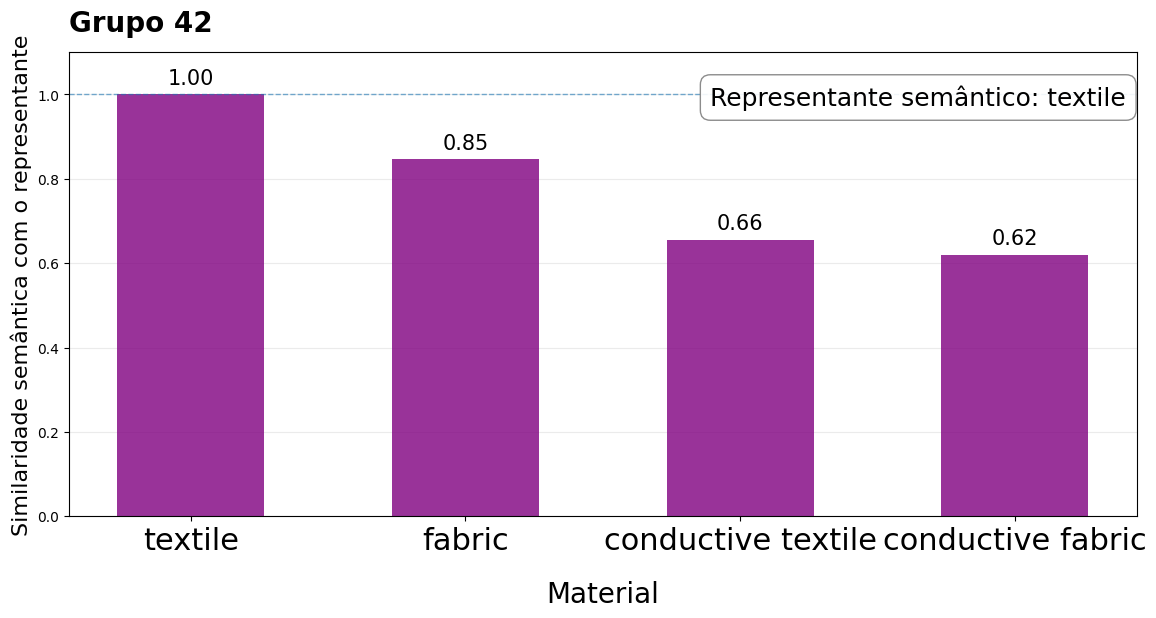

In [22]:
tamanho_grupos = df_grupos["grupo"].value_counts()

tres_maiores = (tamanho_grupos[tamanho_grupos > 1].head(0).index.tolist())

grupo = tres_maiores[0]

representante = representantes[grupo]


# PREPARAR OS DADOS
indice_representante = materiais_validos.index(representante)

indices_grupo = df_grupos.index[df_grupos["grupo"] == grupo].tolist()

dados = []

for indice in indices_grupo:

    material = materiais_validos[indice]

    similaridade = matriz_similaridade[indice_representante, indice]

    dados.append({"material": material, "similaridade": similaridade})


df_temp = pd.DataFrame(dados)


# ORDENAR PELA SIMILARIDADE
df_temp = df_temp.sort_values("similaridade", ascending=False).reset_index(drop=True)


# QUEBRAR NOMES LONGOS
df_temp["material_plot"] = df_temp["material"].apply(lambda x: "\n".join(textwrap.wrap(str(x), width=18)))


# FIGURA
fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(df_temp)) * 1.4

ax.bar(
    x,
    df_temp["similaridade"],
    width=0.75,
    color="purple",
    alpha=0.8
)

for i, valor in enumerate(df_temp["similaridade"]):
    ax.text(
        x[i],
        valor + 0.015,
        f"{valor:.2f}",
        ha="center",
        va="bottom",
        fontsize=15
    )

ax.set_xticks(x)
ax.set_xticklabels(df_temp["material_plot"], fontsize=22)
ax.set_xlabel("Material", fontsize=20, labelpad=18)


ax.set_ylabel("Similaridade semântica com o representante", fontsize=16)
ax.set_ylim(0, 1.10)

ax.axhline(1.0, linestyle="--", linewidth=1, alpha=0.6)

ax.set_title(
    f"Grupo {grupo}",
    fontsize=20,
    fontweight="bold",
    loc="left",
    pad=15
)

ax.text(
    0.99,
    0.93,
    f"Representante semântico: {representante}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=18,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

plt.subplots_adjust(
    left=0.08,
    right=0.97,
    top=0.88,
    bottom=0.30
)

PASTA_SAIDA = "graficos"
plt.savefig(os.path.join(PASTA_SAIDA, f"grupo_{grupo}_similaridade.png"), dpi=300, bbox_inches="tight")

plt.show()

## Resumo do agrupamento

In [14]:
# 1. Agrupar os materiais pertencentes a cada grupo em uma lista
df_resumo_grupos = (df_grupos.groupby("grupo")["material_original"].apply(lambda materiais: ", ".join(sorted(materiais))).reset_index())

# 2. Renomear e adicionar informações de representante e quantidade
df_resumo_grupos.rename(columns={"material_original": "materiais_pertencentes"}, inplace=True)
df_resumo_grupos["representante"] = df_resumo_grupos["grupo"].map(representantes)
df_resumo_grupos["total_materiais"] = df_grupos.groupby("grupo")["material_original"].count().values

# Reordenar as colunas
df_resumo_grupos = df_resumo_grupos[["grupo", "representante", "total_materiais", "materiais_pertencentes"]]

# 3. Salvar em um arquivo Excel com duas abas
ARQUIVO_RELATORIO_GRUPOS = "relatorio_grupos_materiais.xlsx"

with pd.ExcelWriter(ARQUIVO_RELATORIO_GRUPOS) as writer:
    df_resumo_grupos.to_excel(writer, sheet_name="Resumo_por_Grupo", index=False)
    df_agrupado.to_excel(writer, sheet_name="Detalhado", index=False)

print(f"Relatório: '{ARQUIVO_RELATORIO_GRUPOS}'")

Relatório exportado com sucesso para 'relatorio_grupos_materiais.xlsx'!
